In [36]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil
import re
import warnings
warnings.filterwarnings('ignore')
import tifffile
from pathlib import Path
from scipy.spatial import cKDTree

import sys
sys.path.append('../..')

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import SR_Functions
SupRes_F = SR_Functions.SuperRes_Functions(camera="ximea")

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args   = {'sigma': 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = 'image'

In [37]:
# ── Acquisition parameters ─────────────────────────────────────────────────────
DATA_ROOT   = '/media/jbeckwith/Ezra Seagat/20260629_PFS_zStack/'
WORK_DIR    = '/media/jbeckwith/Ezra Seagat/20260629_PFS_zStack_Analysis/'
CAL_DIR     = '../../Camera_Calibrations/Ximea_Camera/'

N_Z_STEPS   = 21         # z-stage positions: -1000 to +1000 nm
N_REPEATS   = 100         # frames acquired at each z position
Z_STEP_NM   = 100        # step size in nm
Z_NM        = np.arange(-1000, 1100, Z_STEP_NM)  # shape (21,)

PIXEL_SIZE  = 69         # nm
NA          = 1.49
PFA         = 1e-4       # spot-detection false-positive rate
ROI_SIZE    = 40

# Excitation channels present in the data
CHANNELS = {

    '488': {
        'folder':       os.path.join(DATA_ROOT, 'PFS_zstack_488'),
        'peak_wl':      0.488,
        'glob_pattern': 'PFS_zstack_488_MMStack_Pos-*.ome.tif',
    },
}

# Minimum fraction of z-planes a spot must appear in to be analysed
MIN_PRESENCE_FRACTION = 0.9
MIN_PLANES = int(np.ceil(MIN_PRESENCE_FRACTION * N_Z_STEPS))

# Minimum photons for an individual localisation to be kept (drops unreliable
# low-SNR fits before the z-plane-presence filter below is applied)
MIN_PHOTONS = 2000

# Minimum colour fraction (A_R / A_G / A_B) for an individual localisation to be
# kept. Applied the same way as MIN_PHOTONS — per-localisation, before the
# z-plane-presence filter. Set an entry to None to disable filtering on that
# channel.
MIN_A_R = None
MIN_A_G = 0.5
MIN_A_B = None

# Spatial matching tolerance for linking the same spot across z-planes (pixels)
MATCH_RADIUS_PX = 1.0

print(f'Z positions (nm): {Z_NM}')
print(f'Min planes for inclusion: {MIN_PLANES} / {N_Z_STEPS}')
print(f'Min photons per localisation: {MIN_PHOTONS}')
print(f'Min colour fractions per localisation: A_R>={MIN_A_R}, A_G>={MIN_A_G}, A_B>={MIN_A_B}')

os.makedirs(WORK_DIR, exist_ok=True)

Z positions (nm): [-1000  -900  -800  -700  -600  -500  -400  -300  -200  -100     0   100
   200   300   400   500   600   700   800   900  1000]
Min planes for inclusion: 19 / 21
Min photons per localisation: 2000
Min colour fractions per localisation: A_R>=None, A_G>=0.5, A_B>=None


In [38]:
# ── Multi-file FOV handling ────────────────────────────────────────────────────
# MicroManager splits an OME-TIFF once a single stack would exceed its internal
# size limit (~4 GB). Each FOV here is N_Z_STEPS * N_REPEATS = 2100 frames,
# larger than that limit, so every FOV now spans two physical files: the main
# file, plus a continuation file with a numeric suffix before the extension:
#   PFS_zstack_638_..._MMStack_Pos-0-0.ome.tif      (first ~1857 frames)
#   PFS_zstack_638_..._MMStack_Pos-0-0_1.ome.tif    (remaining ~243 frames)
# The OME-XML that would normally let tifffile stitch these together is invalid
# for this acquisition ("invalid entry in coordinates array"), which is also why
# the rest of this notebook reads with is_ome=False. The helpers below stitch
# the physical files back into one logical FOV using page counts only (no OME
# metadata needed), so every downstream cell keeps treating "one FOV" as "one
# stack", and the exact frame split point never needs to be hardcoded.

_PART_RE = re.compile(r'^(?P<base>.+)_(?P<part>\d+)\.ome\.tif$')
_PAGE_COUNT_CACHE: dict[str, int] = {}


def build_fov_file_groups(folder, image_type='.ome.tif'):
    """Group a folder's split OME-TIFFs into one ordered file list per FOV.

    Returns {fov_base_name: [main_path, part1_path, part2_path, ...]}, sorted
    in frame order. FOVs with no continuation files get a single-element list.
    """
    all_files = sorted(f for f in os.listdir(folder) if f.endswith(image_type))
    parts_by_base = {}
    mains = []
    for f in all_files:
        m = _PART_RE.match(f)
        if m:
            parts_by_base.setdefault(m.group('base'), []).append((int(m.group('part')), f))
        else:
            mains.append(f)

    groups = {}
    for main in mains:
        base = main[: -len(image_type)]
        parts = [f for _, f in sorted(parts_by_base.get(base, []))]
        groups[base] = [os.path.join(folder, f) for f in [main] + parts]
    return groups


def _n_pages(path):
    key = str(Path(path).resolve())
    if key not in _PAGE_COUNT_CACHE:
        with tifffile.TiffFile(path, is_ome=False) as tf:
            _PAGE_COUNT_CACHE[key] = len(tf.pages)
    return _PAGE_COUNT_CACHE[key]


def fov_total_frames(file_group):
    """Total frame count across all physical files in a FOV group (metadata only)."""
    return sum(_n_pages(fp) for fp in file_group)


def read_full_fov_stack(file_group, dtype=None):
    """Read and concatenate every frame of a (possibly multi-file) FOV."""
    if len(file_group) == 1:
        with tifffile.TiffFile(file_group[0], is_ome=False) as tf:
            out = tf.asarray()
        return out.astype(dtype) if dtype else out

    counts = [_n_pages(fp) for fp in file_group]
    with tifffile.TiffFile(file_group[0], is_ome=False) as tf:
        shape = tf.pages[0].shape
    out = np.empty((sum(counts),) + shape, dtype=dtype or np.uint16)
    offset = 0
    for fp, n in zip(file_group, counts):
        with tifffile.TiffFile(fp, is_ome=False) as tf:
            out[offset:offset + n] = tf.asarray()
        offset += n
    return out


# Discover FOV groups for every channel up front
FOV_GROUPS = {ch_name: build_fov_file_groups(ch_info['folder'])
              for ch_name, ch_info in CHANNELS.items()}

for ch_name, groups in FOV_GROUPS.items():
    n_split = sum(1 for g in groups.values() if len(g) > 1)
    print(f'[{ch_name}] {len(groups)} FOV(s), {n_split} split across multiple files')
    for base, paths in sorted(groups.items()):
        if len(paths) > 1:
            print(f'    {base}: {len(paths)} files -> {[os.path.basename(p) for p in paths]}')

[488] 9 FOV(s), 9 split across multiple files
    PFS_zstack_488_489_MMStack_Pos-0-0: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-0-0.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-0-0_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-0-1: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-0-1.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-0-1_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-0-2: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-0-2.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-0-2_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-1-0: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-1-0.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-1-0_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-1-1: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-1-1.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-1-1_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-1-2: 2 files -> ['PFS_zstack_488_489_MMStack_Pos-1-2.ome.tif', 'PFS_zstack_488_489_MMStack_Pos-1-2_1.ome.tif']
    PFS_zstack_488_489_MMStack_Pos-2-0: 2 files -> ['PFS_zstack_488_489_MMStac

In [39]:
# ── Camera calibration ─────────────────────────────────────────────────────────
gain     = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset   = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))
readnoise = IO.read_tiff(os.path.join(CAL_DIR, 'readnoise.tif'))
rqe      = IO.read_tiff(os.path.join(CAL_DIR, 'rqe.tif'))

print(f'Calibration maps loaded — chip shape: {gain.shape}')

Calibration maps loaded — chip shape: (1544, 2064)


Example FOV: PFS_zstack_488_489_MMStack_Pos-0-0  (2 file(s))
Stack shape: (2100, 996, 1144)  dtype: uint16


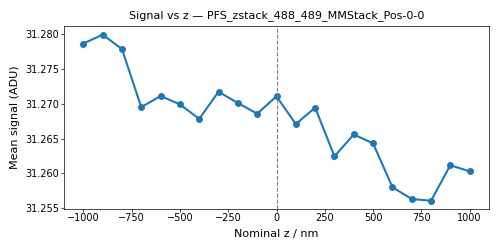

In [40]:
# ── Inspect one stack — verify frame ordering ──────────────────────────────────
# Frame ordering (MicroManager SlicesFirst=True):
#   page_index = z_stage_idx * N_REPEATS + repeat_idx
#   z_stage_idx = 0..20 → z_nm = -1000..+1000 nm
#   repeat_idx  = 0..(N_REPEATS-1)
# Each FOV may span multiple physical files (see FOV_GROUPS above); frames are
# concatenated in file order before reshaping.

example_base  = sorted(FOV_GROUPS['488'].keys())[0]
example_group = FOV_GROUPS['488'][example_base]
print(f'Example FOV: {example_base}  ({len(example_group)} file(s))')

stack = read_full_fov_stack(example_group)   # (N_Z*N_REPEATS, H, W)

print(f'Stack shape: {stack.shape}  dtype: {stack.dtype}')
assert stack.shape[0] == N_Z_STEPS * N_REPEATS, (
    f'Expected {N_Z_STEPS * N_REPEATS} frames, got {stack.shape[0]}')

# Mean signal per z-step — sanity check that the stack is correctly ordered
stack_4d = stack.reshape(N_Z_STEPS, N_REPEATS, stack.shape[1], stack.shape[2])
mean_per_z = stack_4d.mean(axis=(1, 2, 3))
del stack, stack_4d

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(Z_NM, mean_per_z, 'o-', ms=4)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Nominal z / nm')
ax.set_ylabel('Mean signal (ADU)')
ax.set_title(f'Signal vs z — {example_base}')
plt.tight_layout()
plt.show()

[488] Loading PFS_zstack_488_489_MMStack_Pos-0-0 (2 file(s))...
  8 spots detected


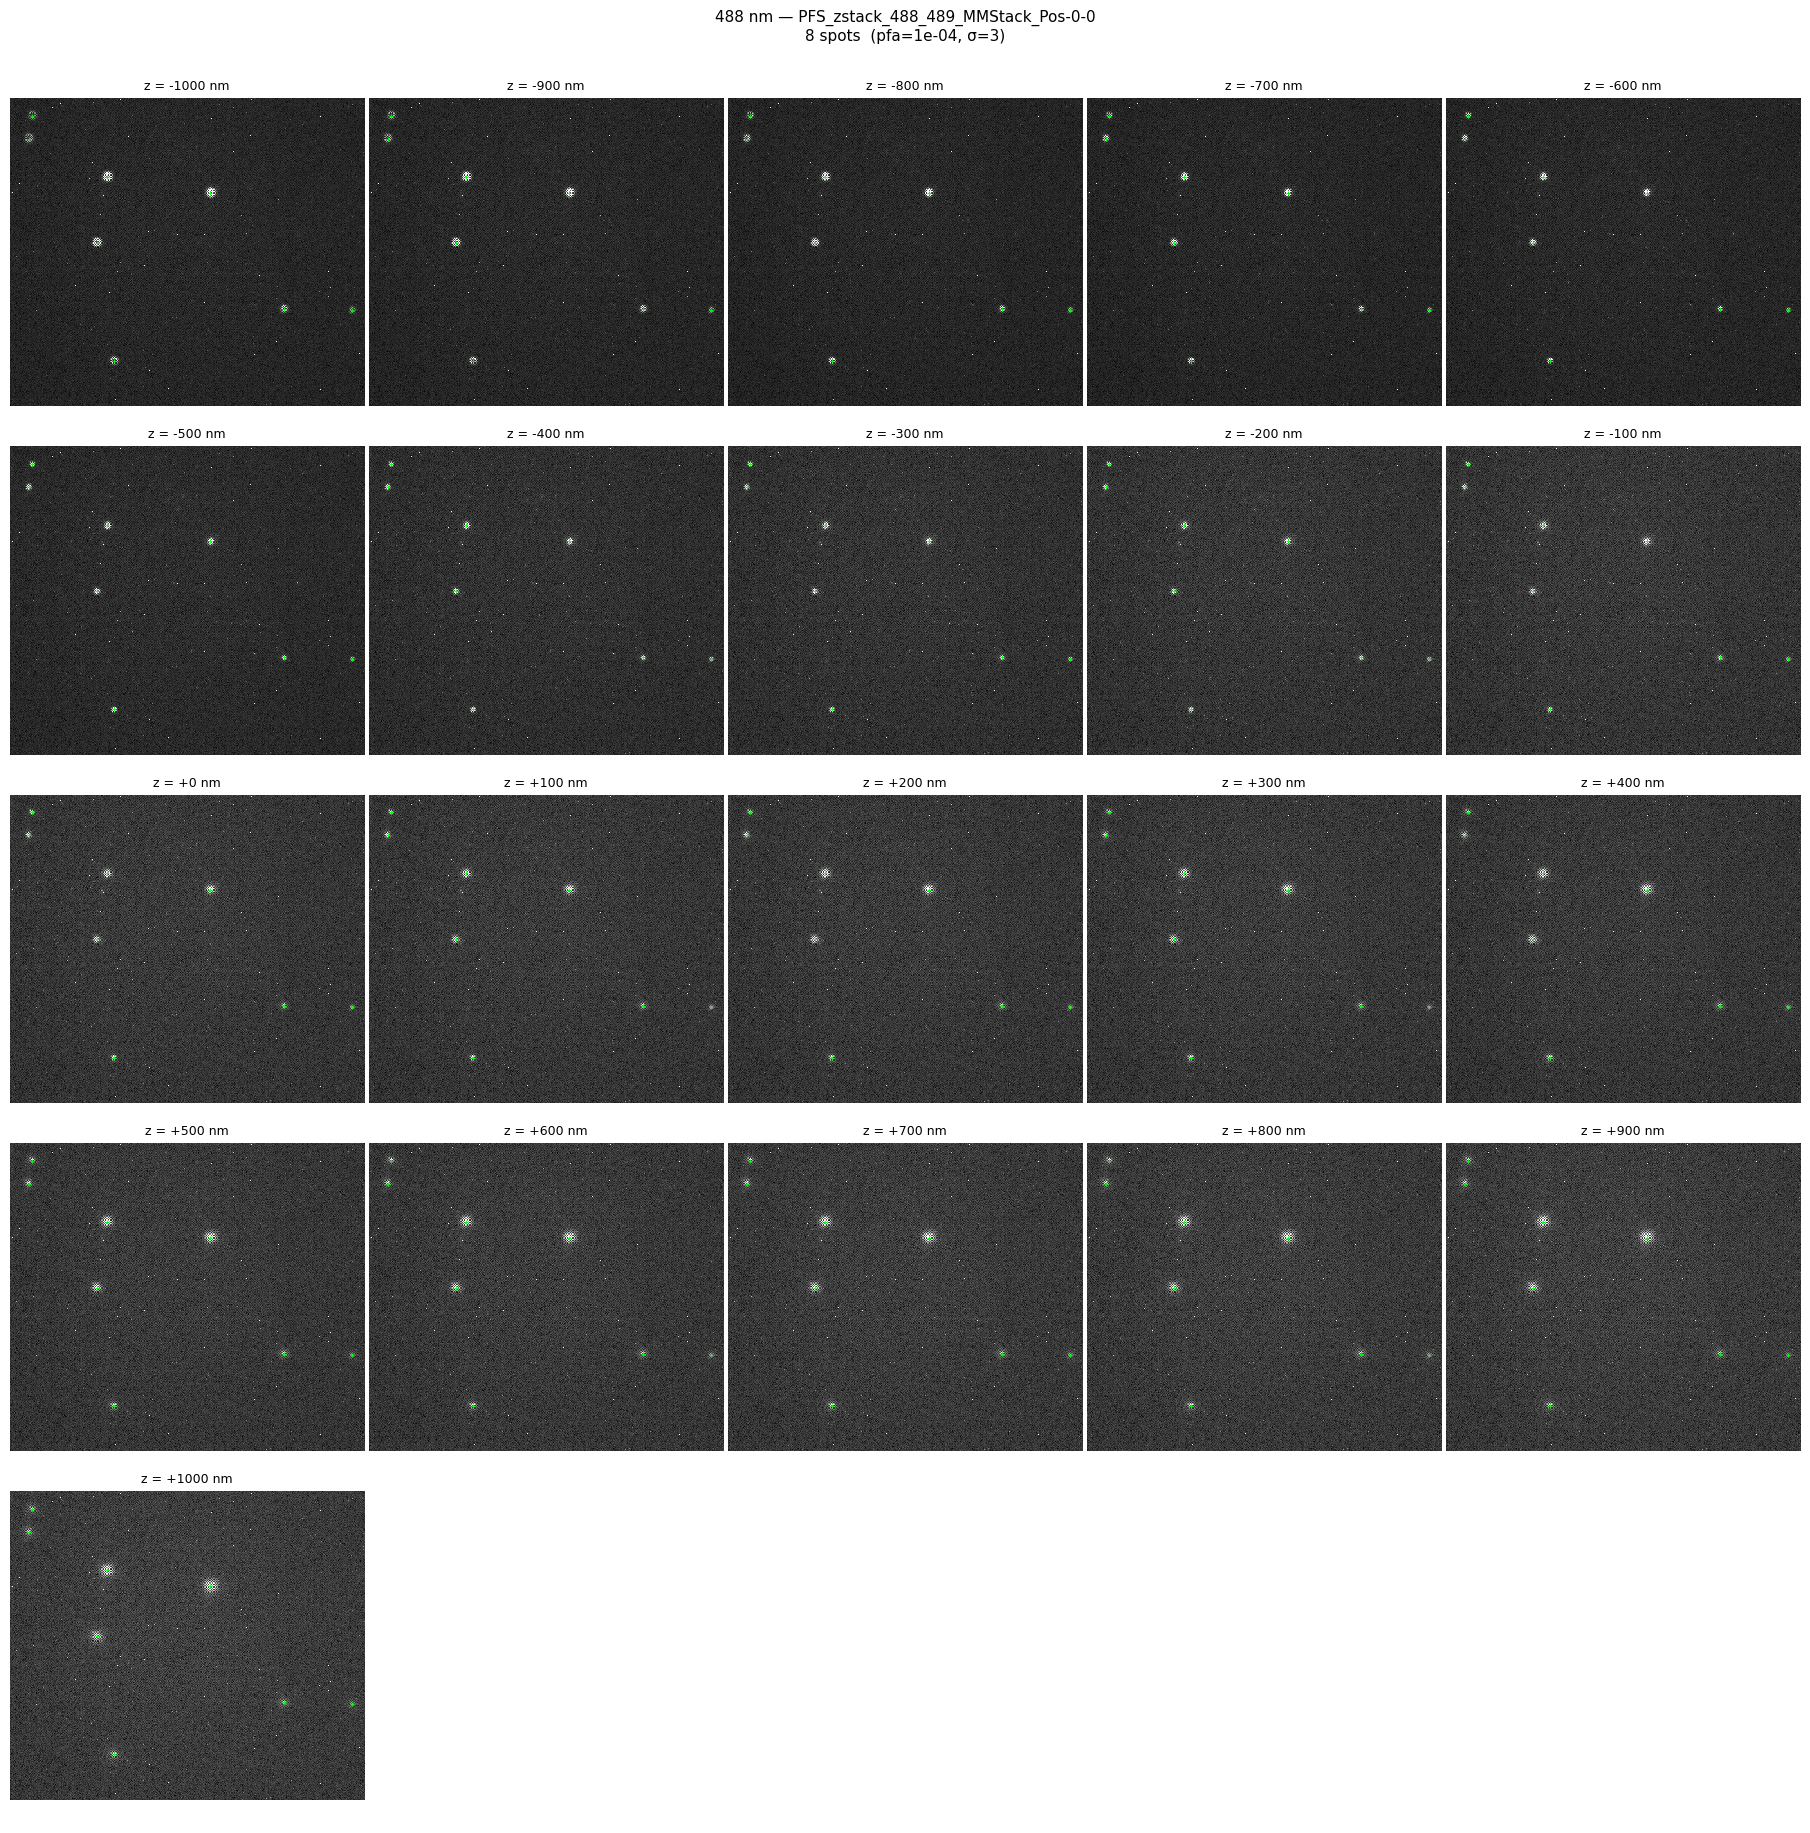

In [41]:
# ── Spot detection preview — tune parameters before running the full fit ───────
# Detection is performed on the sum of ALL N_Z_STEPS*N_REPEATS frames (same as
# fit_QD_data). Each panel shows the summed image for one z-step (N_REPEATS
# repeats) with detected spot positions overlaid. Adjust parameters below and
# re-run until satisfied.

PFA_PREVIEW           = PFA    # lower → fewer but more confident spots
SIGMA_PREVIEW         = 3    # Gaussian detection sigma (pixels)
FRACTION_TRUE_PREVIEW = 0.5    # prior on fraction of pixels containing true spots

GRID_ROWS, GRID_COLS = 5, 5   # 25 slots for 21 z-steps; last 4 left blank

for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    groups = FOV_GROUPS[ch_name]
    if not groups:
        print(f'[{ch_name}] No .ome.tif files found, skipping')
        continue

    example_base  = sorted(groups.keys())[0]
    example_group = groups[example_base]
    print(f'[{ch_name}] Loading {example_base} ({len(example_group)} file(s))...')

    full = read_full_fov_stack(example_group, dtype=np.float32)   # (N_Z*N_REPEATS, H, W)
    full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])

    # Calibration crops (mirrors what fit_QD_data does internally)
    start_x, start_y, width, height = SupRes_F.helper.load_metadata_roi(
        ch_folder, SupRes_F.io, use_fallback=True)
    if width is None:
        height, width = full.shape[1], full.shape[2]
        start_x = start_y = 0

    cropped = SupRes_F.helper.crop_calibration_maps(
        {'gain_map': gain, 'offset_map': offset, 'read_noise': readnoise,
         'rqe': rqe, 'variance': variance},
        start_x, start_y, width, height)
    g_c   = cropped['gain_map']
    o_c   = cropped['offset_map']
    var_c = cropped['variance']

    # Detect on the sum of ALL frames (exactly as fit_QD_data will)
    n_total  = N_Z_STEPS * N_REPEATS
    var_sum  = var_c * n_total
    off_sum  = o_c  * n_total
    summed   = full.sum(axis=0)   # (H, W)

    img_detect = SupRes_F._demosaic_image(
        summed, use_variance_aware=True,
        gain_map=g_c, offset_map=off_sum, variance=var_sum)

    detected = SupRes_F.spot_detection.detect_puncta_in_image(
        img_detect,
        pfa=PFA_PREVIEW,
        variance=var_sum,
        wavelength=ch_info['peak_wl'],
        pixel_size=SupRes_F.pixel_size,
        NA=NA,
        sigma=SIGMA_PREVIEW,
        fraction_true=FRACTION_TRUE_PREVIEW,
    )
    n_spots = len(detected)
    print(f'  {n_spots} spots detected')

    # 5×5 grid: one panel per z-step, unused slots hidden
    fig, axs = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(18, 18))
    axs_flat = axs.ravel()

    for zi in range(GRID_ROWS * GRID_COLS):
        ax = axs_flat[zi]
        if zi >= N_Z_STEPS:
            ax.axis('off')
            continue
        img = full_4d[zi].sum(axis=0).astype(float)
        vmin, vmax = np.percentile(img, [0.1, 99.9])
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax,
                  origin='upper', interpolation='nearest')
        if n_spots > 0:
            ax.scatter(detected[:, 1], detected[:, 0],
                       s=12, marker='+', color='lime', linewidths=0.8, alpha=0.9)
        ax.set_title(f'z = {Z_NM[zi]:+.0f} nm', fontsize=9)
        ax.axis('off')

    plt.suptitle(
        f'{ch_name} nm — {example_base}\n'
        f'{n_spots} spots  (pfa={PFA_PREVIEW:.0e}, σ={SIGMA_PREVIEW})',
        fontsize=11, y=1.01)
    plt.tight_layout(pad=0.5)
    plt.show()

    del full, full_4d, summed, img_detect, detected

In [42]:
# ── Detect spots & fit every frame per molecule ───────────────────────────────
# Strategy:
#   1. Sum ALL N_Z_STEPS*N_REPEATS frames → detect spots once per FOV.
#      In-focus frames dominate the sum; defocused frames add only diffuse background.
#   2. fit_QD_data fits every frame at every detected spot location.
#   3. Results: {FOV}.h5 alongside the FOV's main .ome.tif, with columns:
#        puncta_id, frame, xc, yc, A_B, A_G, A_R, photons, ...
#   Z-centering is done per molecule in a later cell.
#
# Multi-file FOVs: fit_QD_data (SR_Functions.py) assumes one physical file per
# FOV. Each FOV here is split across a main file and a continuation file (see
# FOV_GROUPS above), so three of its collaborators are monkeypatched for the
# duration of this cell, scoped to SupRes_F's own io/helper instances only
# (the notebook's separate top-level `IO` instance from cell 0 is untouched):
#   - helper.file_search      → drop continuation files from the per-channel
#                               FOV list so each FOV is only visited once
#   - io.get_num_pages_in_TIF → report the combined frame count across a FOV's
#                               files
#   - io.read_tiff            → translate a global frame index/list into the
#                               right physical file(s) and stitch the result
#                               back together
# This reuses fit_QD_data's detection / chunked-fitting / save logic unchanged.
# The patches are left in place afterwards; they no-op (fall back to the
# original methods) for any path that isn't one of this dataset's FOV files.

# Relax the PSF-width filter: the default _filter_fit_results rejects s_x/s_y >= 3 px,
# which discards defocused PSFs at extreme z. For this z-scan analysis we only require
# positive sigma; the upper bound is removed.
import types

def _relaxed_filter_fit_results(self, fit_results, width, height):
    mask = (
        fit_results.notna().all(axis=1)
        & (fit_results["xc"] > 0) & (fit_results["xc"] < width)
        & (fit_results["yc"] > 0) & (fit_results["yc"] < height)
        & (fit_results["s_x"] > 0)   # no upper bound — PSF grows with defocus
        & (fit_results["s_y"] > 0)
        & (fit_results["A_B"] > 0) & (fit_results["A_G"] > 0) & (fit_results["A_R"] > 0)
        & (fit_results["bg_B"] > 0) & (fit_results["bg_G"] > 0) & (fit_results["bg_R"] > 0)
    )
    return fit_results[mask].reset_index(drop=True)

SupRes_F._filter_fit_results = types.MethodType(_relaxed_filter_fit_results, SupRes_F)
print('Relaxed sigma filter applied (no upper PSF-width bound).')

_orig_file_search   = type(SupRes_F.helper).file_search
_orig_get_num_pages = type(SupRes_F.io).get_num_pages_in_TIF
_orig_read_tiff     = type(SupRes_F.io).read_tiff


def _make_multipart_patches(file_groups):
    """file_groups: {resolved main-file path: [main_path, part1_path, ...]}"""

    def _patched_file_search(self, folder, string1, string2):
        files = _orig_file_search(self, folder, string1, string2)
        if string1 == '.ome.tif':
            files = [f for f in files if not _PART_RE.match(os.path.basename(f))]
        return files

    def _patched_get_num_pages(self, filename):
        group = file_groups.get(str(Path(filename).resolve()))
        if group is None:
            return _orig_get_num_pages(self, filename)
        return fov_total_frames(group)

    def _patched_read_tiff(self, file_path, frame=None, dtype='float32', memmap=True):
        group = file_groups.get(str(Path(file_path).resolve()))
        if group is None:
            return _orig_read_tiff(self, file_path, frame=frame, dtype=dtype, memmap=memmap)

        counts = [_n_pages(fp) for fp in group]
        bounds = np.cumsum([0] + counts)

        if frame is None:
            return np.concatenate(
                [_orig_read_tiff(self, fp, frame=None, dtype=dtype, memmap=memmap)
                 for fp in group], axis=0)

        single = not hasattr(frame, '__len__')
        frame_arr = np.asarray([frame] if single else frame)

        out = None
        for fp, lo, hi in zip(group, bounds[:-1], bounds[1:]):
            sel = (frame_arr >= lo) & (frame_arr < hi)
            if not sel.any():
                continue
            local = (frame_arr[sel] - lo).tolist()
            data = _orig_read_tiff(self, fp, frame=local if len(local) > 1 else local[0],
                                    dtype=dtype, memmap=memmap)
            if data.ndim == 2:
                data = data[np.newaxis]
            if out is None:
                out = np.empty((len(frame_arr),) + data.shape[1:], dtype=data.dtype)
            out[np.where(sel)[0]] = data

        return out[0] if single else out

    return _patched_file_search, _patched_get_num_pages, _patched_read_tiff


for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    groups = FOV_GROUPS[ch_name]
    if not groups:
        print(f'[{ch_name}] No FOVs found, skipping')
        continue

    h5_count = sum(1 for f in os.listdir(ch_folder) if f.endswith('.h5'))
    if h5_count >= len(groups):
        print(f'[{ch_name}] All {len(groups)} FOV(s) already fitted, skipping')
        print(f'  NOTE: delete the .h5 files and re-run if the filter was previously strict')
        continue

    file_groups_by_main = {
        str(Path(paths[0]).resolve()): paths for paths in groups.values()
    }
    _fs, _gp, _rt = _make_multipart_patches(file_groups_by_main)
    SupRes_F.helper.file_search      = types.MethodType(_fs, SupRes_F.helper)
    SupRes_F.io.get_num_pages_in_TIF = types.MethodType(_gp, SupRes_F.io)
    SupRes_F.io.read_tiff            = types.MethodType(_rt, SupRes_F.io)

    print(f'[{ch_name}] Fitting {len(groups)} FOV(s) — this will take a while...')
    SupRes_F.fit_QD_data(
        image_folder=ch_folder,
        smoothing_function=smoothing_function,
        gain_map=gain,
        offset_map=offset,
        rqe=rqe,
        read_noise=readnoise,
        variance=variance,
        n_frames_sum=N_Z_STEPS * N_REPEATS,   # sum ALL frames for detection
        pfa=PFA,
        ROI_size=ROI_SIZE,
        peak_wavelength=ch_info['peak_wl'],
        NA=NA,
        image_type='.ome.tif',
    )
    print(f'  [{ch_name}] Done.')

print('All fitting complete.')

Relaxed sigma filter applied (no upper PSF-width bound).
[488] All 9 FOV(s) already fitted, skipping
  NOTE: delete the .h5 files and re-run if the filter was previously strict
All fitting complete.


In [43]:
# ── Load fitting results and decode frame → z_step_idx / repeat_idx ──────────
# fit_QD_data stores absolute frame numbers (0..524).
# Encoding: frame = z_step_idx * N_REPEATS + repeat_idx
#
# puncta_id is only unique within a single FOV. A globally unique mol_uid is
# created here so that downstream groupby operations across multiple FOVs
# do not conflate molecules from different fields of view.

all_results = {}

for ch_name, ch_info in CHANNELS.items():
    ch_folder = ch_info['folder']
    h5_files  = sorted(f for f in os.listdir(ch_folder) if f.endswith('.h5'))
    if not h5_files:
        print(f'[{ch_name}] No H5 files found')
        continue

    all_results[ch_name] = {}
    for h5_name in h5_files:
        fov_name = h5_name.replace('.h5', '')
        h5_path  = os.path.join(ch_folder, h5_name)
        try:
            df = pd.read_hdf(h5_path)
        except Exception as e:
            print(f'  Warning: failed to load {h5_path}: {e}')
            continue

        df['z_step_idx'] = (df['frame'] // N_REPEATS).astype(int).clip(0, N_Z_STEPS - 1)
        df['repeat_idx'] = (df['frame']  % N_REPEATS).astype(int)
        df['z_nm']       = Z_NM[df['z_step_idx'].values]
        # Globally unique molecule identifier across all FOVs and channels
        df['mol_uid']    = ch_name + '_' + fov_name + '_' + df['puncta_id'].astype(str)

        all_results[ch_name][fov_name] = df
        n_mol = df['mol_uid'].nunique()
        print(f'  [{ch_name}] {fov_name}: {len(df):,} fits, {n_mol} molecules, '
              f'{df["z_step_idx"].nunique()} z-steps')

print('Load complete.')

  [488] PFS_zstack_488_489_MMStack_Pos-0-0: 32,579 fits, 26 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-0-1: 49,321 fits, 37 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-0-2: 39,355 fits, 34 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-0: 45,553 fits, 33 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-1: 39,344 fits, 31 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-2: 40,028 fits, 31 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-2-0: 37,997 fits, 29 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-2-1: 40,283 fits, 29 molecules, 21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-2-2: 41,907 fits, 31 molecules, 21 z-steps
Load complete.


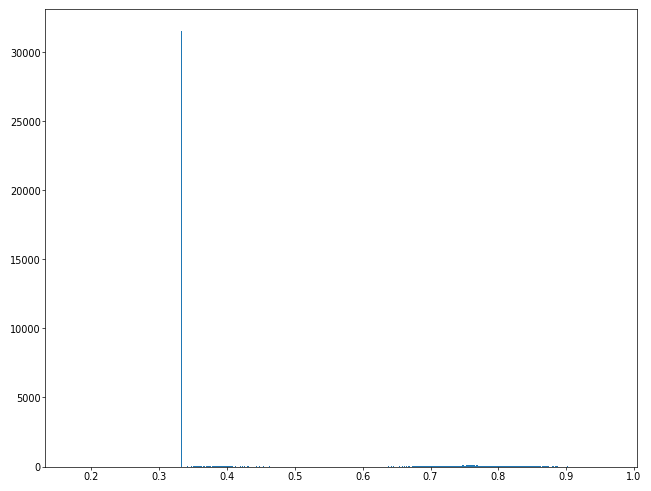

In [44]:
plt.hist(df['A_G'],1000);
plt.show()

In [45]:
df = df[df['A_G'] > 0.5]

In [46]:
# ── Filter molecules by minimum photons, colour fraction, and z-plane presence ─
# Drop individual localisations below MIN_PHOTONS and below the MIN_A_R/MIN_A_G/
# MIN_A_B colour-fraction thresholds (unreliable low-SNR or colour-ambiguous
# fits), then keep only molecules still present in at least MIN_PLANES distinct
# z-steps after those cuts.

COLOUR_MIN = {'A_R': MIN_A_R, 'A_G': MIN_A_G, 'A_B': MIN_A_B}
colour_note = ', '.join(f'{c}>={t}' for c, t in COLOUR_MIN.items() if t is not None)

matched_results = {}

for ch_name, fov_dict in all_results.items():
    matched_results[ch_name] = {}
    for fov_name, df in fov_dict.items():
        df_bright = df[df['photons'] >= MIN_PHOTONS]

        n_after_photons = len(df_bright)
        for col, thresh in COLOUR_MIN.items():
            if thresh is not None:
                df_bright = df_bright[df_bright[col] >= thresh]

        plane_count = df_bright.groupby("mol_uid")["z_step_idx"].nunique()
        good_ids    = plane_count[plane_count >= MIN_PLANES].index
        df_good     = df_bright[df_bright["mol_uid"].isin(good_ids)].copy()

        matched_results[ch_name][fov_name] = df_good
        print(f"  [{ch_name}] {fov_name}: {len(df):,} -> {n_after_photons:,} fits "
              f"≥{MIN_PHOTONS} photons -> {len(df_bright):,} fits"
              + (f" ({colour_note})" if colour_note else "")
              + f"; {len(good_ids)} / {df_bright['mol_uid'].nunique()} "
              f"molecules present in ≥{MIN_PLANES}/{N_Z_STEPS} z-steps")

print("Filtering complete.")

  [488] PFS_zstack_488_489_MMStack_Pos-0-0: 32,579 -> 31,727 fits ≥2000 photons -> 5,995 fits (A_G>=0.5); 7 / 8 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-0-1: 49,321 -> 48,337 fits ≥2000 photons -> 14,378 fits (A_G>=0.5); 14 / 14 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-0-2: 39,355 -> 38,343 fits ≥2000 photons -> 8,602 fits (A_G>=0.5); 9 / 10 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-0: 45,553 -> 44,363 fits ≥2000 photons -> 5,903 fits (A_G>=0.5); 5 / 13 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-1: 39,344 -> 38,700 fits ≥2000 photons -> 10,254 fits (A_G>=0.5); 11 / 12 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-1-2: 40,028 -> 39,296 fits ≥2000 photons -> 12,318 fits (A_G>=0.5); 9 / 11 molecules present in ≥19/21 z-steps
  [488] PFS_zstack_488_489_MMStack_Pos-2-0: 37,997 -> 37,504 fits ≥2000 photons -> 11,292 fits (A_G>=0

In [47]:
# ── Z-centering: global focus z-step ──────────────────────────────────────────
# With the PFS active and beads on the coverslip, all molecules share the same
# focal plane.  Per-molecule centering on 21 noisy sigma estimates introduces
# more error than it corrects.  Instead, find the single z-step with minimum
# mean PSF width across all molecules and channels, then use that as z=0
# for every localisation.

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE

# Pool all channels/FOVs to find the global focus step
all_data = pd.concat(
    [df for fov_dict in matched_results.values() for df in fov_dict.values()],
    ignore_index=True,
)
all_data['sigma_mean'] = (all_data['s_x'] + all_data['s_y']) / 2.0
global_mean_sigma = all_data.groupby('z_step_idx')['sigma_mean'].mean()
global_focus_idx  = int(global_mean_sigma.idxmin())
global_focus_nm   = float(Z_NM[global_focus_idx])

print(f'Global focus: z_step_idx = {global_focus_idx}  '
      f'(z = {global_focus_nm:+.0f} nm nominal)')
print(f'  Mean FWHM at focus: '
      f'{global_mean_sigma[global_focus_idx] * FWHM_FACTOR:.1f} nm')

# Apply the same z=0 to every molecule
centered_results = {}
for ch_name, fov_dict in matched_results.items():
    centered_results[ch_name] = {}
    for fov_name, df in fov_dict.items():
        df = df.copy()
        df['z_rel_nm'] = df['z_nm'] - global_focus_nm
        centered_results[ch_name][fov_name] = df

print('Z-centering complete (global criterion: minimum mean PSF width).')

Global focus: z_step_idx = 11  (z = +100 nm nominal)
  Mean FWHM at focus: 359.8 nm
Z-centering complete (global criterion: minimum mean PSF width).


In [48]:
# ── Precision vs z ─────────────────────────────────────────────────────────────
# σ_xy: for each z-bin, compute the per-molecule mean XY position across its 25
# repeats, then take the RMS of the residuals (actual − mean) and convert to nm.
# This is the localisation precision: how consistently we can place the same
# molecule at the same z-step across repeated exposures.
# Formula: σ_xy = sqrt((std(Δx)² + std(Δy)²) / 2) × pixel_size_nm
#
# σ_col: std of the Euclidean distance of each (A_R, A_G, A_B) vector from its
# per-molecule mean, pooled across all molecules in the z-bin.
#
# A_B, A_G, A_R are already normalised fractions (sum = 1) from write_h5_database.
# mol_uid ensures molecules from different FOVs are never conflated.

colour_cols = [c for c in ['A_R', 'A_G', 'A_B'] if c in next(
    iter(next(iter(centered_results.values())).values())
).columns]
print(f'Colour columns: {colour_cols}  (normalised fractions, sum = 1)')

def precision_per_zbin(df, z_bins, pixel_size_nm=PIXEL_SIZE):
    rows = []
    df = df.copy()
    df['z_bin'] = pd.cut(df['z_rel_nm'], bins=z_bins, labels=False)
    bin_centres = 0.5 * (z_bins[:-1] + z_bins[1:])

    for b_idx, g in df.groupby('z_bin', observed=True):
        if len(g) < 5:
            continue
        # Residuals from per-molecule mean position within this z-bin
        mol_mean_x = g.groupby('mol_uid')['xc'].transform('mean')
        mol_mean_y = g.groupby('mol_uid')['yc'].transform('mean')
        ex = g['xc'] - mol_mean_x
        ey = g['yc'] - mol_mean_y
        sigma_xy = np.sqrt((np.nanstd(ex)**2 + np.nanstd(ey)**2) / 2) * pixel_size_nm

        sigma_col = np.nan
        sigma_R = np.nan
        sigma_G = np.nan
        sigma_B = np.nan

        if len(colour_cols) >= 2:
            col_arr  = g[colour_cols].values.astype(float)
            mean_col = col_arr.mean(axis=0, keepdims=True)
            sigma_col = np.nanstd(np.linalg.norm(col_arr - mean_col, axis=1))
            mol_mean_B = g.groupby('mol_uid')['A_B'].transform('mean')
            mol_mean_G = g.groupby('mol_uid')['A_G'].transform('mean')        
            mol_mean_R = g.groupby('mol_uid')['A_R'].transform('mean')        
            sigma_B = np.nanstd(g['A_B'] - mol_mean_B)
            sigma_G = np.nanstd(g['A_G'] - mol_mean_G)
            sigma_R = np.nanstd(g['A_R'] - mol_mean_R)            
        
        rows.append({
            'z_rel_nm':     float(bin_centres[int(b_idx)]),
            'sigma_xy_nm':  sigma_xy,
            'sigma_colour': sigma_col,
            'sigma_B': sigma_B,
            'sigma_G': sigma_G,
            'sigma_R': sigma_R,
            'n_locs':       len(g),
        })
    return pd.DataFrame(rows)

Z_BINS = np.arange(-1050, 1150, Z_STEP_NM)

precision_by_ch = {}
for ch_name, fov_dict in centered_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    prec   = precision_per_zbin(all_ch, Z_BINS)
    precision_by_ch[ch_name] = prec
    print(f'\n[{ch_name}]')
    print(prec.to_string(index=False))

Colour columns: ['A_R', 'A_G', 'A_B']  (normalised fractions, sum = 1)

[488]
 z_rel_nm  sigma_xy_nm  sigma_colour  sigma_B  sigma_G  sigma_R  n_locs
  -1000.0    15.507086      0.048797 0.025067 0.041901 0.023649    2721
   -900.0    11.697376      0.042373 0.019923 0.036539 0.022851    3201
   -800.0     9.493296      0.036118 0.016544 0.033305 0.022020    3574
   -700.0     7.693705      0.031369 0.013787 0.030502 0.020433    4097
   -600.0     6.303433      0.030091 0.012923 0.031271 0.021189    4533
   -500.0     6.061514      0.027820 0.012037 0.029943 0.020569    4805
   -400.0     5.161981      0.025525 0.011134 0.027551 0.019322    5063
   -300.0     4.421007      0.023809 0.010447 0.025789 0.018260    5082
   -200.0     4.509449      0.024410 0.010790 0.025282 0.017626    5079
   -100.0     4.603273      0.023422 0.010669 0.024490 0.017312    5049
      0.0     5.535172      0.025570 0.011818 0.026009 0.018065    4944
    100.0     5.707777      0.025138 0.012412 0.026556 0.0

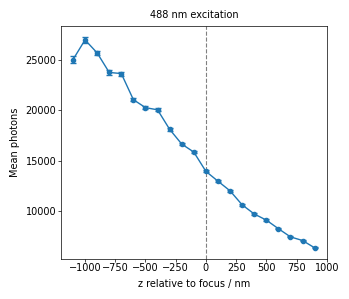

In [49]:
# ── Total photons vs z (sanity check — should peak at z=0) ────────────────────
fs = plotter.config.font_size
n_ch = len(centered_results)
fig, axs = plt.subplots(1, n_ch, figsize=(3.5 * n_ch, 3.0), squeeze=False)

for ax, (ch_name, fov_dict) in zip(axs[0], centered_results.items()):
    all_ch  = pd.concat(list(fov_dict.values()), ignore_index=True)
    mean_ph = all_ch.groupby('z_rel_nm')['photons'].mean()
    sem_ph  = all_ch.groupby('z_rel_nm')['photons'].sem()
    ax.errorbar(mean_ph.index, mean_ph.values, yerr=sem_ph.values,
                fmt='o-', ms=3, lw=1.0, capsize=2)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('z relative to focus / nm', fontsize=fs)
    ax.set_ylabel('Mean photons', fontsize=fs)
    ax.set_title(f'{ch_name} nm excitation', fontsize=fs)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'photons_vs_z.svg'), dpi=300, format='svg')
plt.show()

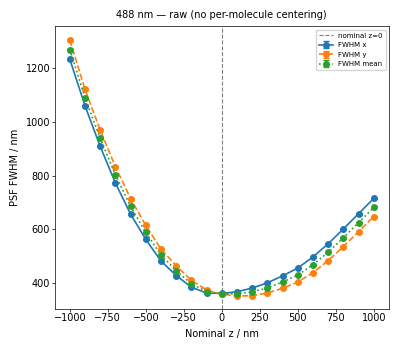


[488] mean FWHM (nm) per z-step:
 z_nm        mean  count
-1000 1267.781494   1968
 -900 1089.705078   2721
 -800  938.537048   3201
 -700  802.405090   3574
 -600  684.996826   4097
 -500  588.212646   4533
 -400  503.993225   4805
 -300  446.073334   5063
 -200  397.184082   5082
 -100  368.552887   5079
    0  360.034363   5049
  100  359.807617   4944
  200  367.257629   4870
  300  381.993805   4857
  400  403.820679   4809
  500  429.892181   4613
  600  468.214600   4514
  700  515.008545   4345
  800  568.621887   4150
  900  624.935730   3794
 1000  681.341736   3464


In [50]:
# ── Diagnostic: raw PSF FWHM vs absolute z-step (no centering) ────────────────
# Before trusting the per-molecule z-centering, verify the raw data is sensible.
# Average s_x and s_y over ALL molecules at each z_step_idx and plot as FWHM.
# A well-behaved dataset should show a clear minimum at the in-focus z-step
# regardless of any per-molecule z-centering.

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE

n_ch = len(matched_results)
fig, axs = plt.subplots(1, n_ch, figsize=(4.0 * n_ch, 3.5), squeeze=False)
fs = plotter.config.font_size

for ax, (ch_name, fov_dict) in zip(axs[0], matched_results.items()):
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    all_ch['fwhm_x']    = all_ch['s_x'] * FWHM_FACTOR
    all_ch['fwhm_y']    = all_ch['s_y'] * FWHM_FACTOR
    all_ch['fwhm_mean'] = (all_ch['fwhm_x'] + all_ch['fwhm_y']) / 2.0

    grp = all_ch.groupby('z_step_idx')
    for col, label, ls in [('fwhm_x',    'FWHM x',    '-'),
                            ('fwhm_y',    'FWHM y',    '--'),
                            ('fwhm_mean', 'FWHM mean', ':')]:
        m = grp[col].mean()
        s = grp[col].sem()
        ax.errorbar(Z_NM[m.index], m.values, yerr=s.values,
                    fmt='o' + ls, ms=4, lw=1.2, capsize=2, label=label)

    ax.axvline(0, color='gray', lw=0.8, ls='--', label='nominal z=0')
    ax.set_xlabel('Nominal z / nm', fontsize=fs)
    ax.set_ylabel('PSF FWHM / nm', fontsize=fs)
    ax.set_title(f'{ch_name} nm — raw (no per-molecule centering)', fontsize=fs)
    ax.legend(fontsize=fs - 2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'psf_fwhm_vs_z_raw.svg'), dpi=300, format='svg')
plt.show()

# Also print the raw mean FWHM at each z-step for quick inspection
for ch_name, fov_dict in matched_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)
    all_ch['fwhm_mean'] = (all_ch['s_x'] + all_ch['s_y']) / 2.0 * FWHM_FACTOR
    summary = all_ch.groupby('z_step_idx')['fwhm_mean'].agg(['mean','count']).reset_index()
    summary['z_nm'] = Z_NM[summary['z_step_idx'].values]
    print(f'\n[{ch_name}] mean FWHM (nm) per z-step:')
    print(summary[['z_nm','mean','count']].to_string(index=False))

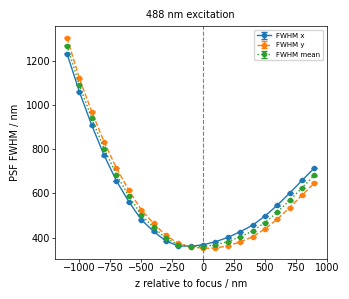

In [51]:
# ── PSF FWHM vs z ──────────────────────────────────────────────────────────────
# s_x, s_y are Gaussian σ in pixels.  FWHM = 2√(2 ln 2) × σ × pixel_size_nm.
# Should be minimum at z_rel = 0 (this is the centering criterion).

FWHM_FACTOR = 2 * np.sqrt(2 * np.log(2)) * PIXEL_SIZE   # px → nm conversion

n_ch = len(centered_results)
fig, axs = plt.subplots(1, n_ch, figsize=(3.5 * n_ch, 3.0), squeeze=False)
fs = plotter.config.font_size

for ax, (ch_name, fov_dict) in zip(axs[0], centered_results.items()):
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)

    # Mean FWHM per z-bin (100 nm = one z-step)
    all_ch['fwhm_x'] = all_ch['s_x'] * FWHM_FACTOR
    all_ch['fwhm_y'] = all_ch['s_y'] * FWHM_FACTOR
    all_ch['fwhm_mean'] = (all_ch['fwhm_x'] + all_ch['fwhm_y']) / 2.0

    grp = all_ch.groupby('z_rel_nm')
    for col, label, ls in [('fwhm_x', 'FWHM x', '-'),
                            ('fwhm_y', 'FWHM y', '--'),
                            ('fwhm_mean', 'FWHM mean', ':')]:
        m = grp[col].mean()
        s = grp[col].sem()
        ax.errorbar(m.index, m.values, yerr=s.values,
                    fmt='o' + ls, ms=3, lw=1.0, capsize=2, label=label)

    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('z relative to focus / nm', fontsize=fs)
    ax.set_ylabel('PSF FWHM / nm', fontsize=fs)
    ax.set_title(f'{ch_name} nm excitation', fontsize=fs)
    ax.legend(fontsize=fs - 2)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'psf_fwhm_vs_z.svg'), dpi=300, format='svg')
plt.show()

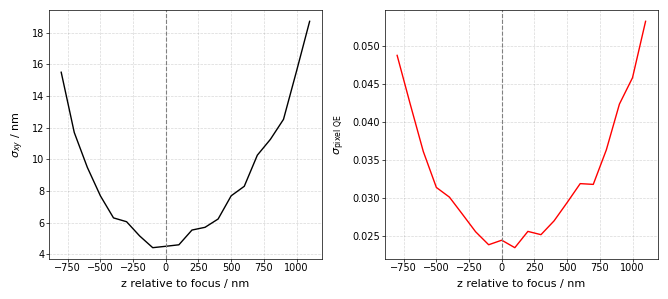

In [52]:
# ── Localisation and colour precision vs z ────────────────────────────────────
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1,1])

for col_idx, (ch_name, prec) in enumerate(precision_by_ch.items()):
    ax_xy  = axs[0]
    ax_col = axs[1]

    # σ_xy
    ax_xy = plotter.line_plot(ax_xy, prec['z_rel_nm']+200, prec['sigma_xy_nm'], linewidth=1)
    ax_xy.axvline(0, color='gray', lw=0.8, ls='--')
    ax_xy.set_xlabel('z relative to focus / nm', fontsize=fs+1)
    ax_xy.set_ylabel(r'$\sigma_{xy}$ / nm', fontsize=fs+1)

    # σ_colour
    if prec['sigma_colour'].notna().any():
        ax_col = plotter.line_plot(ax_col, prec['z_rel_nm']+200, prec['sigma_colour'], color='red')
        ax_col.axvline(0, color='gray', lw=0.8, ls='--')
        ax_col.set_xlabel('z relative to focus / nm', fontsize=fs+1)
        ax_col.set_ylabel(r'$\sigma_{\rm pixel\ QE}$', fontsize=fs+1)
    else:
        ax_col.text(0.5, 0.5, 'No colour data', ha='center', va='center',
                    transform=ax_col.transAxes, color='gray')

plt.tight_layout()

#save_dir = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Z_Defocus/'
#plt.savefig(os.path.join(save_dir, f'precision_vs_z.svg'), dpi=300, format='svg')
plt.show()

[488][PFS_zstack_488_489_MMStack_Pos-0-0] 7 candidate molecules (indices 0..6):
  [  0] 488_PFS_zstack_488_489_MMStack_Pos-0-0_12  <-- selected
  [  1] 488_PFS_zstack_488_489_MMStack_Pos-0-0_19  <-- selected
  [  2] 488_PFS_zstack_488_489_MMStack_Pos-0-0_2  <-- selected
  [  3] 488_PFS_zstack_488_489_MMStack_Pos-0-0_22  <-- selected
  [  4] 488_PFS_zstack_488_489_MMStack_Pos-0-0_4  <-- selected
  [  5] 488_PFS_zstack_488_489_MMStack_Pos-0-0_5  <-- selected
  [  6] 488_PFS_zstack_488_489_MMStack_Pos-0-0_6


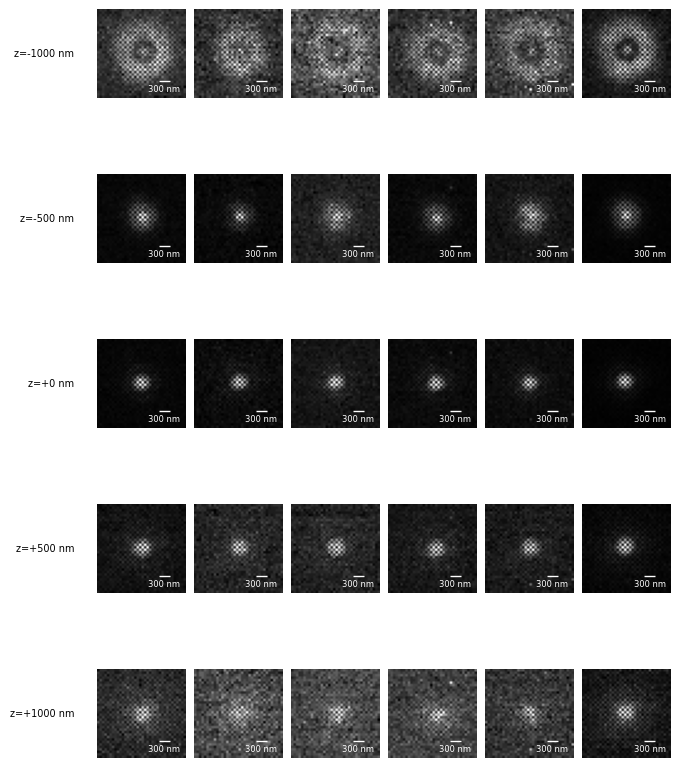

In [53]:
# ── Exemplar single-molecule PSF images across z ────────────────────────────────────────────
# 5 columns × 5 rows grid: each column is a different molecule (PSF), each row a
# different z position. The crop is centred on that molecule's mean fitted (xc, yc)
# position, averaged over ALL of its localisations — i.e. one fixed centre per
# molecule, reused for every row, since the emitter doesn't move laterally with z
# and a fixed window avoids apparent drift between rows. By default each panel is
# a max-intensity projection (MIP) across the N_REPEATS frames at that z-step; set
# FRAME_IDX to an int to show one specific repeat frame instead of the MIP.

CH_SHOW     = next(iter(centered_results))       # excitation channel key to display
FOV_SHOW    = None                                # None -> first FOV for CH_SHOW
MOL_INDICES = [0, 1, 2, 3, 4, 5]                      # indices into the sorted mol_uid list (5 columns)
Z_POSITIONS = [-1000, -500, 0, 500, 1000]          # nm relative to focus (5 rows)
CROP_SIZE   = 36                                   # px, ROI edge length around the molecule centre
FRAME_IDX   = 5                                 # None -> MIP over repeats; int -> that repeat frame

if FRAME_IDX is not None:
    assert 0 <= FRAME_IDX < N_REPEATS, f'FRAME_IDX must be in [0, {N_REPEATS})'

fov_show = FOV_SHOW or sorted(centered_results[CH_SHOW].keys())[0]
df_show  = centered_results[CH_SHOW][fov_show]
df_show.z_nm = df_show.z_nm + 200

candidate_mol_uids = sorted(df_show['mol_uid'].unique())
print(f'[{CH_SHOW}][{fov_show}] {len(candidate_mol_uids)} candidate molecules '
      f'(indices 0..{len(candidate_mol_uids) - 1}):')
for i, muid in enumerate(candidate_mol_uids):
    marker = '  <-- selected' if i in MOL_INDICES else ''
    print(f'  [{i:3d}] {muid}{marker}')

if max(MOL_INDICES) >= len(candidate_mol_uids):
    raise ValueError(
        f'MOL_INDICES {MOL_INDICES} out of range — only '
        f'{len(candidate_mol_uids)} candidate molecules available.'
    )
mol_uids = [candidate_mol_uids[i] for i in MOL_INDICES]

# One fixed (xc, yc) centre per molecule: mean over all its localisations
mol_centres = {
    muid: (float(df_show.loc[df_show['mol_uid'] == muid, 'xc'].mean()),
           float(df_show.loc[df_show['mol_uid'] == muid, 'yc'].mean()))
    for muid in mol_uids
}

# Load the raw stack for this FOV once
example_group = FOV_GROUPS[CH_SHOW][fov_show]
full    = read_full_fov_stack(example_group)
full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])
del full
height, width = full_4d.shape[2], full_4d.shape[3]
half = CROP_SIZE // 2

# Map each requested z position (nm relative to focus) -> nearest z_step index
z_step_idxs = [int(np.argmin(np.abs(Z_NM - (global_focus_nm + z)))) for z in Z_POSITIONS]

n_rows, n_cols = len(Z_POSITIONS), len(mol_uids)
fig, axs = plotter.two_column_plot(nrows=n_rows, ncols=n_cols, width_ratios=np.ones(n_cols), height_ratios=np.ones(n_rows))
fig.patch.set_facecolor('white')
fig.set_frameon(True)

for col, muid in enumerate(mol_uids):
    xc, yc = mol_centres[muid]
    x0, x1 = int(round(xc)) - half, int(round(xc)) + half
    y0, y1 = int(round(yc)) - half, int(round(yc)) + half
    x0c, x1c = max(x0, 0), min(x1, width)
    y0c, y1c = max(y0, 0), min(y1, height)
    pad_left, pad_top = max(0, -x0), max(0, -y0)

    for row, (z_target, zi) in enumerate(zip(Z_POSITIONS, z_step_idxs)):
        ax = axs[row, col]

        img = (full_4d[zi, FRAME_IDX] if FRAME_IDX is not None
               else full_4d[zi].max(axis=0)).astype(float)

        crop = np.zeros((CROP_SIZE, CROP_SIZE))
        crop[pad_top:pad_top + (y1c - y0c), pad_left:pad_left + (x1c - x0c)] = (
            img[y0c:y1c, x0c:x1c]
        )

        ax = plotter.image_plot(ax, crop, scalebarlabel='300 nm', scalebarsize=300, scalebar=True,
                               vmax=np.percentile(crop, 99.9), vmin=np.percentile(crop, 0.1))[0]

        if col == 0:
            ax.text(-0.25, 0.5, f'z={z_target:+.0f} nm',
                    transform=ax.transAxes, fontsize=7, ha='right', va='center')


save_dir = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Z_Defocus/'
#plt.savefig(os.path.join(save_dir, f'exemplar_psfs_grid_{CH_SHOW}.svg'), dpi=300, format='svg')
plt.show()
del full_4d

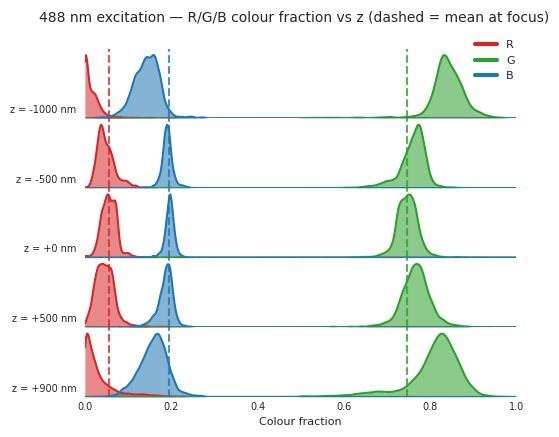

In [56]:
# ── Ridge plot: R/G/B pixel QE (colour fraction) vs Z ───────────────────────────
# Single seaborn-styled ridge plot (one column) with all three colour fractions
# (A_R, A_G, A_B) overlaid on each row, one row per z position (same
# Z_POSITIONS as the exemplar-PSF grid above). Coloured R/G/B to match
# notebooks/figures/SI/FigureSI_MolecularPosition.ipynb (tab:red / tab:green /
# tab:blue for A_R / A_G / A_B respectively).
#
# Curves are computed manually with gaussian_kde (rather than via sns.kdeplot's
# automatic per-group rendering) so every curve — regardless of its underlying
# spread — can be normalised to peak at the same height (1.0); colour-fraction
# spread varies a lot with defocus (tight in-focus vs. broad/mixed far from
# it), and true, unnormalised KDE curves would make broad rows look flat next
# to tight ones. Rows are NOT allowed to overlap (hspace=0) now that heights
# are fixed, so this is a plain stacked small-multiples grid rather than a
# true overlapping "ridgeline" — easier to read exact per-row bias off, at the
# cost of the compact ridgeline look.
#
# Dashed vertical lines mark each channel's mean value at focus (z_rel_nm ==
# 0); the offset between a row's peak and its reference line is the
# colour-fraction estimation bias introduced by defocus at that z.

import seaborn as sns
from scipy.stats import gaussian_kde

CHANNEL_COLOURS = {'R': 'tab:red', 'G': 'tab:green', 'B': 'tab:blue'}
CHANNEL_COLUMNS = {'R': 'A_R', 'G': 'A_G', 'B': 'A_B'}
RIDGE_QE_RANGE  = (0.0, 1.0)
qe_x_grid       = np.linspace(*RIDGE_QE_RANGE, 400)

for ch_name, fov_dict in centered_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)

    missing = [c for c in CHANNEL_COLUMNS.values() if c not in all_ch.columns]
    if missing:
        print(f'[{ch_name}] Missing columns {missing}, skipping colour-QE ridge plot')
        continue

    ref_vals = {ch: float(all_ch.loc[all_ch['z_rel_nm'] == 0, col].mean())
                for ch, col in CHANNEL_COLUMNS.items()}

    z_avail    = np.array(sorted(all_ch['z_rel_nm'].unique()))
    z_used     = [float(z_avail[np.argmin(np.abs(z_avail - z))]) for z in Z_POSITIONS]
    row_labels = {z: f'z = {z:+.0f} nm' for z in z_used}
    row_order  = [row_labels[z] for z in z_used]

    values_by_z = {
        z: {ch: all_ch.loc[all_ch['z_rel_nm'] == z, col].values
            for ch, col in CHANNEL_COLUMNS.items()}
        for z in z_used
    }

    # Dummy frame just to give FacetGrid its row scaffold/styling — the actual
    # curves are drawn manually below, not via g.map(sns.kdeplot, ...).
    scaffold_df = pd.DataFrame({'row_label': row_order})

    with sns.axes_style('white', rc={'axes.facecolor': (0, 0, 0, 0)}):
        g = sns.FacetGrid(scaffold_df, row='row_label', row_order=row_order,
                           aspect=6, height=0.8, xlim=RIDGE_QE_RANGE)

        for ax, z in zip(g.axes.flat, z_used):
            ax.axhline(0, color='black', lw=0.8)
            for ch, color in CHANNEL_COLOURS.items():
                vals = np.asarray(values_by_z[z][ch], dtype=float)
                vals = vals[np.isfinite(vals)]
                kde  = gaussian_kde(vals, bw_method=0.15)
                y    = kde(qe_x_grid)
                y    = y / y.max()   # normalise every curve to the same peak height
                ax.fill_between(qe_x_grid, 0, y, color=color, alpha=0.55, linewidth=0)
                ax.plot(qe_x_grid, y, color=color, linewidth=1.5)
                ax.axvline(ref_vals[ch], color=color, lw=1.5, ls='--', alpha=0.8)
            ax.set_ylim(0, 1.1)
            ax.text(-0.02, 0.05, row_labels[z], fontsize=7, ha='right', va='bottom',
                    transform=ax.transAxes)

        g.figure.subplots_adjust(hspace=0.0)   # rows stacked, not overlapping
        g.set_titles('')
        g.set(yticks=[], ylabel='')
        g.set_xlabels('Colour fraction')
        g.despine(bottom=True, left=True)

        handles = [plt.Line2D([0], [0], color=c, lw=3, label=ch)
                   for ch, c in CHANNEL_COLOURS.items()]
        g.figure.legend(handles=handles, loc='upper right',
                         bbox_to_anchor=(0.98, 0.98), fontsize=8, frameon=False)
        g.figure.suptitle(
            f'{ch_name} nm excitation — R/G/B colour fraction vs z '
            f'(dashed = mean at focus)', fontsize=10, y=1.03,
        )

    g.figure.patch.set_facecolor('white')
    save_dir = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Z_Defocus/'
    g.savefig(os.path.join(save_dir, f'ridge_colour_qe_vs_z_{ch_name}.svg'),
              dpi=300, format='svg', bbox_inches='tight', facecolor='white')
    plt.show()

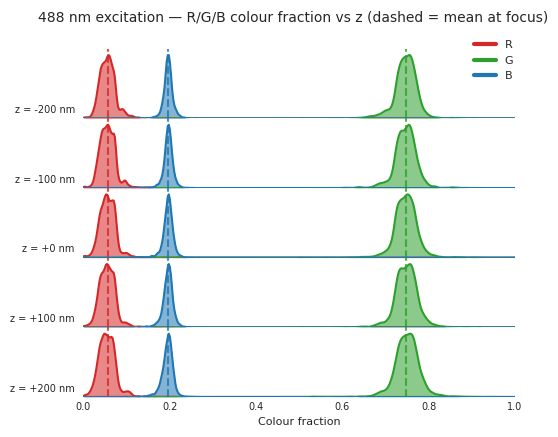

In [57]:
# ── Ridge plot: R/G/B pixel QE (colour fraction) vs Z ───────────────────────────
# Single seaborn-styled ridge plot (one column) with all three colour fractions
# (A_R, A_G, A_B) overlaid on each row, one row per z position (same
# Z_POSITIONS as the exemplar-PSF grid above). Coloured R/G/B to match
# notebooks/figures/SI/FigureSI_MolecularPosition.ipynb (tab:red / tab:green /
# tab:blue for A_R / A_G / A_B respectively).
#
# Curves are computed manually with gaussian_kde (rather than via sns.kdeplot's
# automatic per-group rendering) so every curve — regardless of its underlying
# spread — can be normalised to peak at the same height (1.0); colour-fraction
# spread varies a lot with defocus (tight in-focus vs. broad/mixed far from
# it), and true, unnormalised KDE curves would make broad rows look flat next
# to tight ones. Rows are NOT allowed to overlap (hspace=0) now that heights
# are fixed, so this is a plain stacked small-multiples grid rather than a
# true overlapping "ridgeline" — easier to read exact per-row bias off, at the
# cost of the compact ridgeline look.
#
# Dashed vertical lines mark each channel's mean value at focus (z_rel_nm ==
# 0); the offset between a row's peak and its reference line is the
# colour-fraction estimation bias introduced by defocus at that z.

import seaborn as sns
from scipy.stats import gaussian_kde

Z_POSITIONS = [-200, -100, 0, 100, 200]          # nm relative to focus (5 rows)

CHANNEL_COLOURS = {'R': 'tab:red', 'G': 'tab:green', 'B': 'tab:blue'}
CHANNEL_COLUMNS = {'R': 'A_R', 'G': 'A_G', 'B': 'A_B'}
RIDGE_QE_RANGE  = (0.0, 1.0)
qe_x_grid       = np.linspace(*RIDGE_QE_RANGE, 400)

for ch_name, fov_dict in centered_results.items():
    all_ch = pd.concat(list(fov_dict.values()), ignore_index=True)

    missing = [c for c in CHANNEL_COLUMNS.values() if c not in all_ch.columns]
    if missing:
        print(f'[{ch_name}] Missing columns {missing}, skipping colour-QE ridge plot')
        continue

    ref_vals = {ch: float(all_ch.loc[all_ch['z_rel_nm'] == 0, col].mean())
                for ch, col in CHANNEL_COLUMNS.items()}

    z_avail    = np.array(sorted(all_ch['z_rel_nm'].unique()))
    z_used     = [float(z_avail[np.argmin(np.abs(z_avail - z))]) for z in Z_POSITIONS]
    row_labels = {z: f'z = {z:+.0f} nm' for z in z_used}
    row_order  = [row_labels[z] for z in z_used]

    values_by_z = {
        z: {ch: all_ch.loc[all_ch['z_rel_nm'] == z, col].values
            for ch, col in CHANNEL_COLUMNS.items()}
        for z in z_used
    }

    # Dummy frame just to give FacetGrid its row scaffold/styling — the actual
    # curves are drawn manually below, not via g.map(sns.kdeplot, ...).
    scaffold_df = pd.DataFrame({'row_label': row_order})

    with sns.axes_style('white', rc={'axes.facecolor': (0, 0, 0, 0)}):
        g = sns.FacetGrid(scaffold_df, row='row_label', row_order=row_order,
                           aspect=6, height=0.8, xlim=RIDGE_QE_RANGE)

        for ax, z in zip(g.axes.flat, z_used):
            ax.axhline(0, color='black', lw=0.8)
            for ch, color in CHANNEL_COLOURS.items():
                vals = np.asarray(values_by_z[z][ch], dtype=float)
                vals = vals[np.isfinite(vals)]
                kde  = gaussian_kde(vals, bw_method=0.15)
                y    = kde(qe_x_grid)
                y    = y / y.max()   # normalise every curve to the same peak height
                ax.fill_between(qe_x_grid, 0, y, color=color, alpha=0.55, linewidth=0)
                ax.plot(qe_x_grid, y, color=color, linewidth=1.5)
                ax.axvline(ref_vals[ch], color=color, lw=1.5, ls='--', alpha=0.8)
            ax.set_ylim(0, 1.1)
            ax.text(-0.02, 0.05, row_labels[z], fontsize=7, ha='right', va='bottom',
                    transform=ax.transAxes)

        g.figure.subplots_adjust(hspace=0.0)   # rows stacked, not overlapping
        g.set_titles('')
        g.set(yticks=[], ylabel='')
        g.set_xlabels('Colour fraction')
        g.despine(bottom=True, left=True)

        handles = [plt.Line2D([0], [0], color=c, lw=3, label=ch)
                   for ch, c in CHANNEL_COLOURS.items()]
        g.figure.legend(handles=handles, loc='upper right',
                         bbox_to_anchor=(0.98, 0.98), fontsize=8, frameon=False)
        g.figure.suptitle(
            f'{ch_name} nm excitation — R/G/B colour fraction vs z '
            f'(dashed = mean at focus)', fontsize=10, y=1.03,
        )

    g.figure.patch.set_facecolor('white')
    save_dir = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Z_Defocus/'
    g.savefig(os.path.join(save_dir, f'ridge_colour_qe_vs_z_{ch_name}_small.svg'),
              dpi=300, format='svg', bbox_inches='tight', facecolor='white')
    plt.show()

In [ ]:
# ── Example detections across z-planes (fitted positions on summed images) ─────
# For each shown z-step: sum the N_REPEATS repeats → background image,
# then overlay the fitted (xc, yc) positions of all molecules at that z-step.
# Uses centered_results so z_rel_nm is available.

show_z_rel = [-1000, -500, 0, 500, 1000]  # nm relative to each molecule's focus

ch_show    = '638'
fov_show   = sorted(centered_results.get(ch_show, {}).keys())[0]
df_show    = centered_results[ch_show][fov_show]

# Load the original (possibly multi-file) stack for this FOV
example_group = FOV_GROUPS[ch_show][fov_show]
full = read_full_fov_stack(example_group)
full_4d = full.reshape(N_Z_STEPS, N_REPEATS, full.shape[1], full.shape[2])
del full

# Match z_rel targets to actual z_step indices (use z_nm - per-FOV most common peak)
# For display: just use nominal z_nm steps closest to the requested z_rel values
show_z_idx = [int(np.argmin(np.abs(Z_NM - z))) for z in show_z_rel]

fig, axs = plt.subplots(1, len(show_z_idx),
                         figsize=(2.5 * len(show_z_idx), 2.8), squeeze=True)

for ax, zi in zip(axs, show_z_idx):
    # Summed image for this z-step (N_REPEATS repeats)
    img = full_4d[zi].sum(axis=0).astype(float)
    vmin, vmax = np.percentile(img, [0.5, 99.9])
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='upper',
              interpolation='nearest')

    # Overlay fitted positions at this z-step
    df_zi = df_show[df_show['z_step_idx'] == zi]
    if len(df_zi) > 0:
        # Average repeated fits at this z-step per molecule
        pos = df_zi.groupby('puncta_id')[['xc', 'yc']].mean()
        ax.scatter(pos['xc'], pos['yc'], s=12, marker='+',
                   color='lime', linewidths=0.8, alpha=0.8)

    ax.set_title(f'z={Z_NM[zi]:+.0f} nm\n{len(df_zi["puncta_id"].unique()) if len(df_zi) else 0} mols',
                 fontsize=7)
    ax.axis('off')

plt.suptitle(f'{ch_show} nm — {fov_show}  (summed {N_REPEATS} frames, lime = fits)',
             fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f'example_detections_{ch_show}.svg'), dpi=300, format='svg')
plt.show()
del full_4d